In [1]:
import arviz as az
import bambi as bmb
import numpy as np
import polars as pl

from matplotlib import pyplot as plt

az.rcParams["data.load"] = "eager"

In [2]:
def plot_measurements(ax, df, ycol="value"):
    groups = ("gtyp", "age", "sex")
    n_group = df.select(pl.struct(*groups).n_unique()).item()
    group_df = (
        df.select(groups).unique()
        .sort(groups)
        .pipe(lambda d: d.with_columns(xtick_x=np.linspace(0, 1, len(d))))
        .with_columns(xtick_label=pl.concat_str(groups, separator=","))
    )
    group_to_x = df.group_by(groups)
    plot_df = (
        df
        .join(group_df, on=groups)
        .sort(groups)
        .with_columns(
            scatter_x=pl.col("xtick_x") + np.random.normal(size=len(df), scale=0.01),
            color=pl.when(gtyp="fa/+").then(pl.lit("black")).otherwise(pl.lit("red")),
            marker=pl.when(sex="M").then(pl.lit("^")).otherwise(pl.lit("o")),
        )
    )
    for _, subdf in plot_df.group_by("sex", maintain_order=True):
        ax.scatter(subdf["scatter_x"], subdf[ycol], color=subdf["color"], marker=subdf["marker"][0])
    ax.set_xticks(group_df["xtick_x"], group_df["xtick_label"], fontsize="x-small");
    return ax, plot_df


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.906,0.231,1.478,2.343,0.004,0.004,4027.0,3141.0,1.00
gtyp[fa/fa],1.382,0.504,0.380,2.292,0.010,0.008,2588.0,2753.0,1.00
age[Young],-0.026,0.308,-0.586,0.573,0.005,0.006,3778.0,2670.0,1.00
sex[M],-0.419,0.297,-0.980,0.138,0.005,0.005,3985.0,2936.0,1.00
"gtyp:age[fa/fa, Young]",0.032,0.633,-1.165,1.191,0.011,0.011,3555.0,3111.0,1.00
"gtyp:sex[fa/fa, M]",0.327,0.616,-0.815,1.481,0.011,0.010,3085.0,2832.0,1.00
sigma_Intercept,-0.522,0.198,-0.880,-0.151,0.003,0.004,3847.0,2347.0,1.01
sigma_gtyp[fa/fa],0.609,0.273,0.123,1.157,0.004,0.006,3756.0,2598.0,1.00


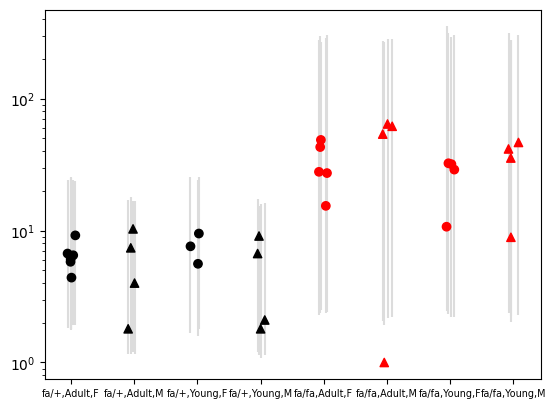

In [3]:
variable = "urine_flow_vehicle"
msts = pl.read_csv(f"../data/prepared/{variable}.csv")
idata = az.from_netcdf(f"../results/idata_{variable}.nc")
display(az.summary(idata, var_names=["~mu", "~sigma"]))
qlow, qhigh = idata.posterior_predictive["log_value"].quantile([0.025, 0.975], dim=["chain", "draw"]).to_numpy()

f, ax = plt.subplots()
ax, plot_df = plot_measurements(ax, msts)
ax.vlines(plot_df["scatter_x"], np.exp(qlow), np.exp(qhigh), zorder=-1, color="gainsboro");
ax.semilogy();

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.023,0.372,-0.782,0.625,0.006,0.006,3357.0,3146.0,1.0
gtyp[fa/fa],2.140,0.596,1.014,3.233,0.011,0.010,2714.0,2393.0,1.0
age[Young],0.076,0.521,-0.919,1.002,0.010,0.008,2926.0,2729.0,1.0
sex[M],0.191,0.515,-0.785,1.088,0.010,0.008,2526.0,2693.0,1.0
"gtyp:age[fa/fa, Young]",0.195,0.780,-1.247,1.678,0.015,0.012,2811.0,2883.0,1.0
"gtyp:sex[fa/fa, M]",-0.258,0.757,-1.746,1.130,0.016,0.012,2228.0,2555.0,1.0
sigma_Intercept,-0.046,0.202,-0.403,0.346,0.004,0.004,3299.0,2398.0,1.0
sigma_gtyp[fa/fa],0.173,0.269,-0.372,0.646,0.004,0.005,3632.0,2677.0,1.0


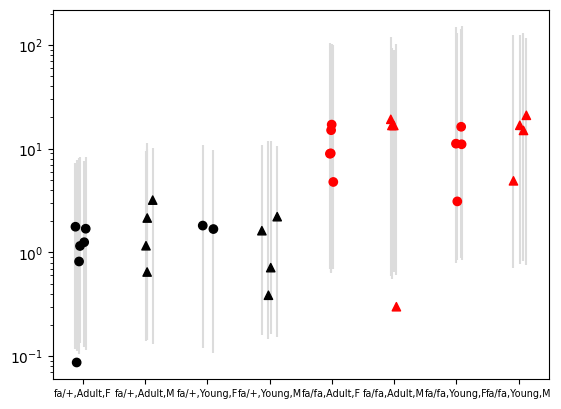

In [4]:
variable = "excretion_glucose_vehicle"
msts = pl.read_csv(f"../data/prepared/{variable}.csv")
idata = az.from_netcdf(f"../results/idata_{variable}.nc")
display(az.summary(idata, var_names=["~mu", "~sigma"]))
qlow, qhigh = idata.posterior_predictive["log_value"].quantile([0.025, 0.975], dim=["chain", "draw"]).to_numpy()

f, ax = plt.subplots()
ax, plot_df = plot_measurements(ax, msts)
ax.vlines(plot_df["scatter_x"], np.exp(qlow), np.exp(qhigh), zorder=-1, color="gainsboro");
ax.semilogy();

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.285,0.473,-1.200,0.623,0.009,0.008,2788.0,2801.0,1.0
gtyp[fa/fa],0.521,0.659,-0.662,1.822,0.013,0.011,2384.0,2553.0,1.0
age[Young],0.222,0.729,-1.119,1.648,0.016,0.015,2110.0,2136.0,1.0
sex[M],-1.056,0.708,-2.449,0.257,0.016,0.014,2099.0,2247.0,1.0
"gtyp:age[fa/fa, Young]",-0.177,0.925,-1.912,1.586,0.020,0.017,2114.0,2079.0,1.0
"gtyp:sex[fa/fa, M]",0.484,0.901,-1.297,2.065,0.020,0.016,2040.0,2294.0,1.0
sigma_Intercept,-0.031,0.268,-0.525,0.475,0.005,0.005,2613.0,2259.0,1.0
sigma_gtyp[fa/fa],0.192,0.328,-0.436,0.790,0.006,0.005,2961.0,2563.0,1.0


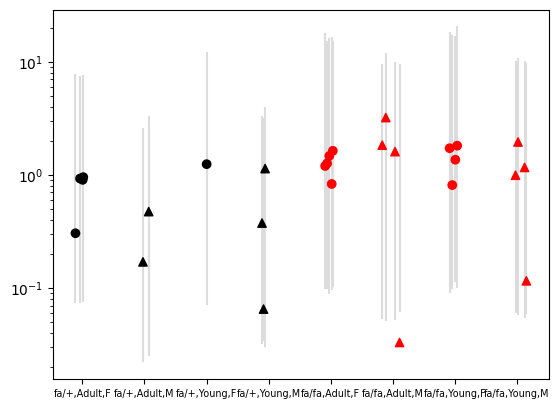

In [5]:
variable = "excretion_na_vehicle"
msts = pl.read_csv(f"../data/prepared/{variable}.csv")
idata = az.from_netcdf(f"../results/idata_{variable}.nc")
display(az.summary(idata, var_names=["~mu", "~sigma"]))
qlow, qhigh = idata.posterior_predictive["log_value"].quantile([0.025, 0.975], dim=["chain", "draw"]).to_numpy()

f, ax = plt.subplots()
ax, plot_df = plot_measurements(ax, msts)
ax.vlines(plot_df["scatter_x"], np.exp(qlow), np.exp(qhigh), zorder=-1, color="gainsboro");
ax.semilogy();

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,4.687,0.018,4.652,4.723,0.000,0.000,3827.0,3131.0,1.0
gtyp[fa/fa],-0.064,0.046,-0.155,0.023,0.001,0.001,2287.0,2467.0,1.0
age[Young],0.004,0.025,-0.041,0.054,0.000,0.000,3027.0,2494.0,1.0
sex[M],-0.036,0.025,-0.085,0.009,0.000,0.001,2923.0,2652.0,1.0
"gtyp:age[fa/fa, Young]",-0.013,0.059,-0.129,0.091,0.001,0.001,2746.0,2458.0,1.0
"gtyp:sex[fa/fa, M]",0.087,0.059,-0.029,0.191,0.001,0.001,2689.0,2802.0,1.0
sigma_Intercept,-3.017,0.198,-3.347,-2.614,0.004,0.003,2840.0,2151.0,1.0
sigma_gtyp[fa/fa],0.772,0.272,0.241,1.258,0.005,0.005,2984.0,2673.0,1.0


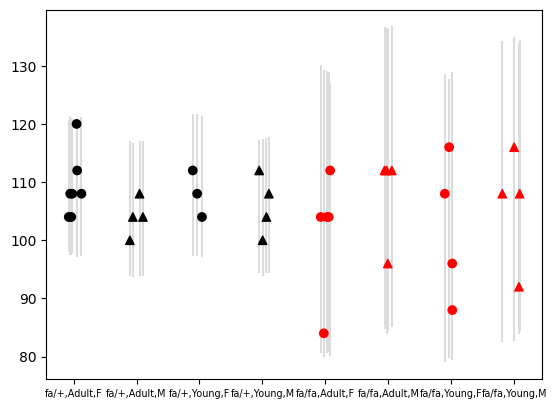

In [6]:
variable = "plasma_na_vehicle"
msts = pl.read_csv(f"../data/prepared/{variable}.csv")
idata = az.from_netcdf(f"../results/idata_{variable}.nc")
display(az.summary(idata, var_names=["~mu", "~sigma"]))
qlow, qhigh = idata.posterior_predictive["log_value"].quantile([0.025, 0.975], dim=["chain", "draw"]).to_numpy()

f, ax = plt.subplots()
ax, plot_df = plot_measurements(ax, msts)
ax.vlines(plot_df["scatter_x"], np.exp(qlow), np.exp(qhigh), zorder=-1, color="gainsboro");

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,2.619,0.841,1.000,4.151,0.015,0.014,3005.0,2871.0,1.0
gtyp[fa/fa],-1.075,1.203,-3.502,1.027,0.023,0.021,2659.0,2523.0,1.0
age[Young],-0.899,1.222,-3.087,1.450,0.027,0.021,1996.0,2196.0,1.0
sex[M],0.216,1.148,-1.999,2.301,0.023,0.021,2470.0,2305.0,1.0
"gtyp:age[fa/fa, Young]",-0.720,1.633,-3.923,2.236,0.036,0.028,2104.0,1995.0,1.0
"gtyp:sex[fa/fa, M]",1.274,1.609,-1.714,4.335,0.032,0.029,2453.0,2257.0,1.0


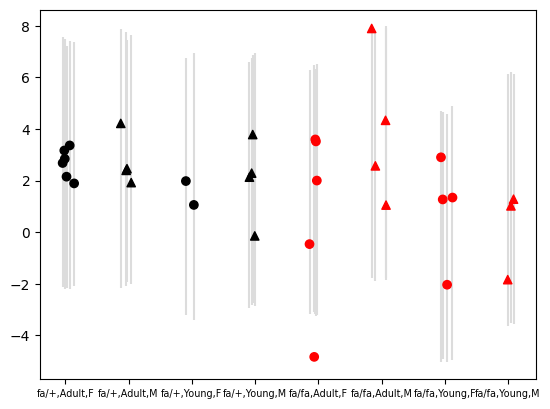

In [7]:
variable = "excretion_glucose_empa_minus_vehicle"
msts = pl.read_csv(f"../data/prepared/{variable}.csv")
idata = az.from_netcdf(f"../results/idata_{variable}.nc")
display(az.summary(idata, var_names=["~mu", "~sigma"]))
qlow, qhigh = idata.posterior_predictive["value"].quantile([0.025, 0.975], dim=["chain", "draw"]).to_numpy()

f, ax = plt.subplots()
ax, plot_df = plot_measurements(ax, msts)
ax.vlines(plot_df["scatter_x"], qlow, qhigh, zorder=-1, color="gainsboro");


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.043,0.113,-0.182,0.243,0.002,0.002,4310.0,3167.0,1.0
gtyp[fa/fa],0.357,0.396,-0.389,1.135,0.008,0.007,2535.0,2086.0,1.0
age[Young],0.077,0.168,-0.222,0.404,0.004,0.004,2261.0,1893.0,1.0
sex[M],-0.173,0.169,-0.486,0.149,0.003,0.004,2473.0,2023.0,1.0
"gtyp:age[fa/fa, Young]",-0.309,0.481,-1.145,0.635,0.009,0.008,2972.0,2639.0,1.0
"gtyp:sex[fa/fa, M]",0.821,0.512,-0.192,1.736,0.010,0.009,2738.0,2260.0,1.0
sigma_Intercept,-1.502,0.303,-2.069,-0.966,0.007,0.005,2031.0,2009.0,1.0
sigma_gtyp[fa/fa],1.426,0.340,0.807,2.054,0.008,0.005,2090.0,2183.0,1.0


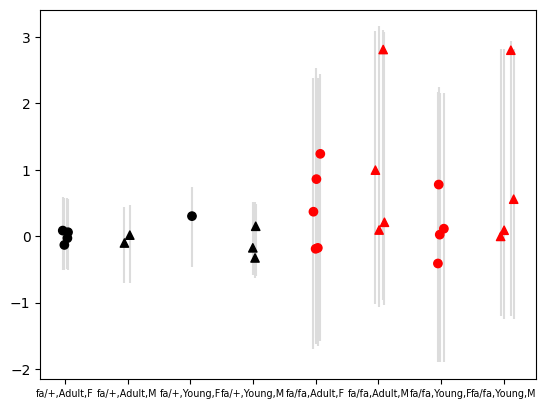

In [8]:
variable = "excretion_na_empa_minus_vehicle"
msts = pl.read_csv(f"../data/prepared/{variable}.csv")
idata = az.from_netcdf(f"../results/idata_{variable}.nc")
display(az.summary(idata, var_names=["~mu", "~sigma"]))
qlow, qhigh = idata.posterior_predictive["value"].quantile([0.025, 0.975], dim=["chain", "draw"]).to_numpy()

f, ax = plt.subplots()
ax, plot_df = plot_measurements(ax, msts)
ax.vlines(plot_df["scatter_x"], qlow, qhigh, zorder=-1, color="gainsboro");


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,5.215,3.101,-0.557,10.980,0.056,0.051,3109.0,2546.0,1.0
gtyp[fa/fa],9.064,4.807,-0.509,17.596,0.099,0.083,2361.0,2447.0,1.0
age[Young],0.411,4.429,-8.358,8.438,0.090,0.073,2405.0,2724.0,1.0
sex[M],3.951,4.202,-4.099,11.771,0.084,0.071,2510.0,2509.0,1.0
"gtyp:age[fa/fa, Young]",-0.255,6.245,-11.588,11.721,0.132,0.112,2245.0,2402.0,1.0
"gtyp:sex[fa/fa, M]",-8.193,6.219,-20.138,3.134,0.130,0.110,2294.0,2157.0,1.0


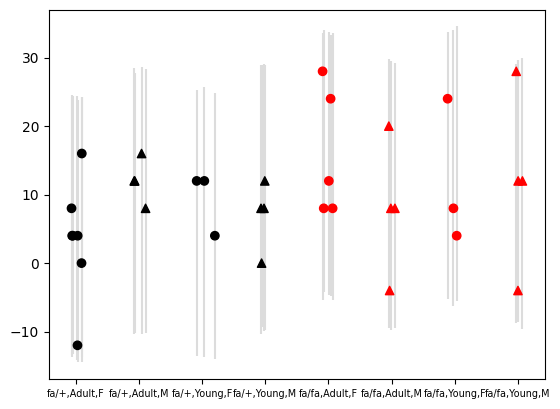

In [9]:
variable = "plasma_na_empa_minus_vehicle"
msts = pl.read_csv(f"../data/prepared/{variable}.csv")
idata = az.from_netcdf(f"../results/idata_{variable}.nc")
display(az.summary(idata, var_names=["~mu", "~sigma"]))
qlow, qhigh = idata.posterior_predictive["value"].quantile([0.025, 0.975], dim=["chain", "draw"]).to_numpy()

f, ax = plt.subplots()
ax, plot_df = plot_measurements(ax, msts)
ax.vlines(plot_df["scatter_x"], qlow, qhigh, zorder=-1, color="gainsboro");